# Data Preprocessing

## Importing

In [1]:
from feast import FeatureStore
from utils import *

/home/marcos/mle-specialization-03/mles3-env/lib/python3.11/site-packages/pydantic/_internal/_config.py:295: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.10/migration/
  warnings.warn(DEPRECATION_MESSAGE, DeprecationWarning)
/home/marcos/mle-specialization-03/mles3-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading and Cleaning

In [2]:
df_companies_stock_raw = pd.read_csv("../data/raw/stock_details_5_years.csv")

In [3]:
df_companies_stock_raw.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
0,2018-11-29 00:00:00-05:00,43.829761,43.863354,42.639594,43.083508,167080000,0.00,0.0,AAPL
1,2018-11-29 00:00:00-05:00,104.769074,105.519257,103.534595,104.636131,28123200,0.00,0.0,MSFT
2,2018-11-29 00:00:00-05:00,54.176498,55.007500,54.099998,54.729000,31004000,0.00,0.0,GOOGL
3,2018-11-29 00:00:00-05:00,83.749496,84.499496,82.616501,83.678497,132264000,0.00,0.0,AMZN
4,2018-11-29 00:00:00-05:00,39.692784,40.064904,38.735195,39.037853,54917200,0.04,0.0,NVDA


In [4]:
df_companies_stock = df_companies_stock_raw.copy()

In [5]:
df_companies_stock.drop(DROP_FEATURES, axis=1, inplace=True)

In [6]:
"""
Renaming features
"""
df_companies_stock = renaming_features(dataframe=df_companies_stock)

In [7]:
"""
Stripping object features
"""
df_companies_stock = stripping_object_features(dataframe=df_companies_stock)

Stripping the columns: ['Date', 'Company']


In [8]:
df_companies_stock.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock_Splits,Company
0,2018-11-29 00:00:00-05:00,43.829761,43.863354,42.639594,43.083508,167080000,0.00,0.0,AAPL
1,2018-11-29 00:00:00-05:00,104.769074,105.519257,103.534595,104.636131,28123200,0.00,0.0,MSFT
2,2018-11-29 00:00:00-05:00,54.176498,55.007500,54.099998,54.729000,31004000,0.00,0.0,GOOGL
3,2018-11-29 00:00:00-05:00,83.749496,84.499496,82.616501,83.678497,132264000,0.00,0.0,AMZN
4,2018-11-29 00:00:00-05:00,39.692784,40.064904,38.735195,39.037853,54917200,0.04,0.0,NVDA


## Analyzing

In [9]:
df_companies_stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602962 entries, 0 to 602961
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Date          602962 non-null  object 
 1   Open          602962 non-null  float64
 2   High          602962 non-null  float64
 3   Low           602962 non-null  float64
 4   Close         602962 non-null  float64
 5   Volume        602962 non-null  int64  
 6   Dividends     602962 non-null  float64
 7   Stock_Splits  602962 non-null  float64
 8   Company       602962 non-null  object 
dtypes: float64(6), int64(1), object(2)
memory usage: 41.4+ MB


In [10]:
df_companies_stock.describe()

,Open,High,Low,Close,Volume,Dividends,Stock_Splits
count,602962.000000,602962.000000,602962.000000,602962.000000,6.029620e+05,602962.00000,602962.000000
mean,140.074711,141.853492,138.276316,140.095204,5.895601e+06,0.00731,0.000344
std,275.401725,279.003191,271.895276,275.477969,1.381596e+07,0.12057,0.050607
min,1.052425,1.061195,1.026114,1.034884,0.000000e+00,0.00000,0.000000
25%,39.566159,40.056222,39.058151,39.563746,1.031500e+06,0.00000,0.000000
50%,79.177964,80.125563,78.193820,79.177906,2.228700e+06,0.00000,0.000000
75%,157.837190,159.746317,155.841609,157.847153,5.277400e+06,0.00000,0.000000
max,6490.259766,6525.000000,6405.000000,6509.350098,1.123003e+09,35.00000,20.000000


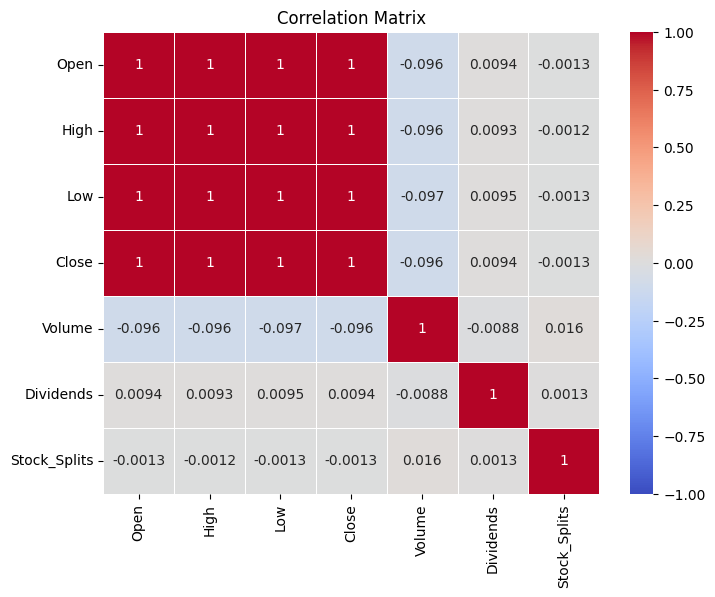

In [11]:
graphing_correlation_matrix(dataframe=df_companies_stock[INITIAL_NUMERICAL_FEATURES], zoom = 2)

array([[<Axes: title={'center': 'Open'}>,
        <Axes: title={'center': 'High'}>,
        <Axes: title={'center': 'Low'}>],
       [<Axes: title={'center': 'Close'}>,
        <Axes: title={'center': 'Volume'}>,
        <Axes: title={'center': 'Dividends'}>],
       [<Axes: title={'center': 'Stock_Splits'}>, <Axes: >, <Axes: >]],
      dtype=object)

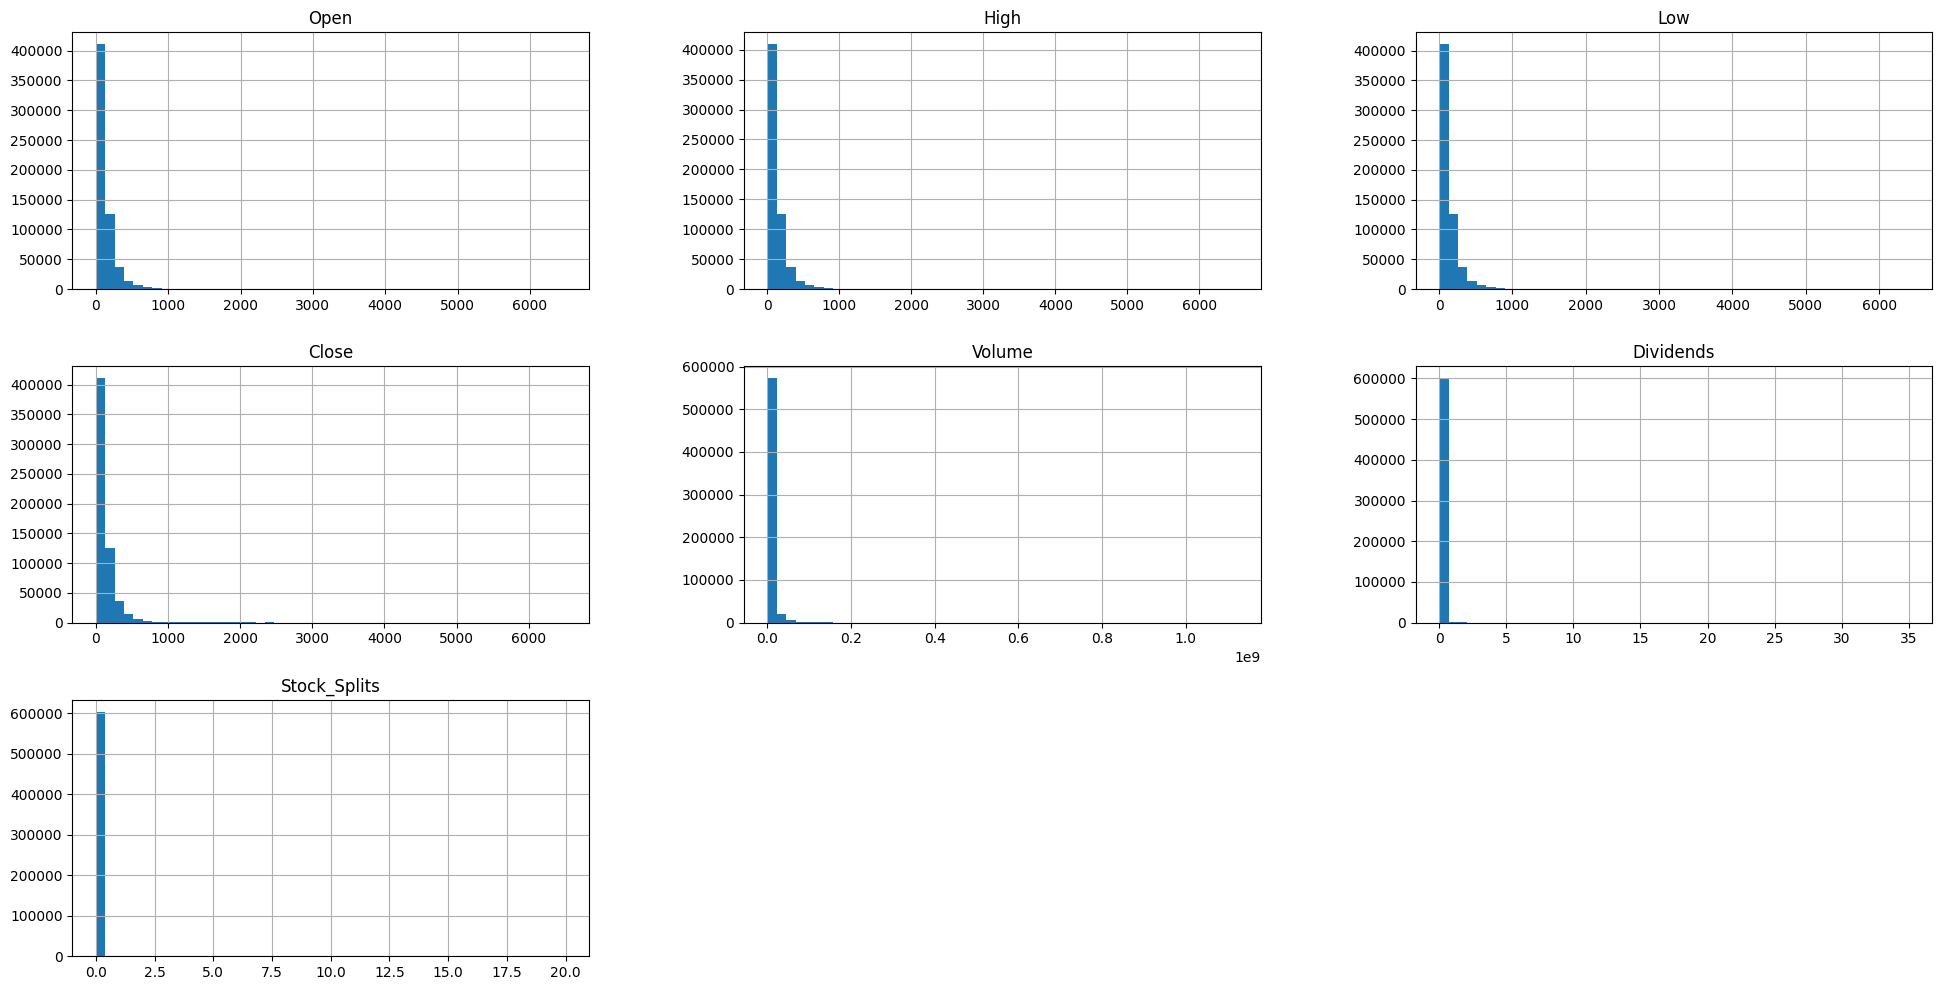

In [12]:
df_companies_stock.hist(bins=50, figsize=(24,12))

In [13]:
object_features_report(df_companies_stock)

********************Unique Counts********************
Date       1258
Company     491
dtype: int64

********************Unique Values********************
Feature 'Date': ['2018-11-29 00:00:00-05:00' '2018-11-30 00:00:00-05:00'
 '2018-12-03 00:00:00-05:00' ... '2023-11-27 00:00:00-05:00'
 '2023-11-28 00:00:00-05:00' '2023-11-29 00:00:00-05:00']
Feature 'Company': ['AAPL' 'MSFT' 'GOOGL' 'AMZN' 'NVDA' 'META' 'TSLA' 'LLY' 'V' 'TSM' 'UNH'
 'AVGO' 'NVO' 'JPM' 'WMT' 'XOM' 'MA' 'JNJ' 'PG' 'ORCL' 'HD' 'ADBE' 'ASML'
 'CVX' 'COST' 'TM' 'MRK' 'KO' 'ABBV' 'BAC' 'PEP' 'FMX' 'CRM' 'SHEL' 'ACN'
 'NFLX' 'MCD' 'AMD' 'LIN' 'NVS' 'AZN' 'CSCO' 'TMO' 'BABA' 'INTC' 'PDD'
 'SAP' 'ABT' 'TMUS' 'PFE' 'DIS' 'NKE' 'CMCSA' 'DHR' 'INTU' 'TTE' 'WFC'
 'VZ' 'BHP' 'HDB' 'HSBC' 'PM' 'QCOM' 'IBM' 'AMGN' 'TXN' 'NOW' 'BA' 'COP'
 'UNP' 'BX' 'SPGI' 'UPS' 'GE' 'MS' 'HON' 'CAT' 'AMAT' 'BUD' 'AXP' 'RY'
 'NEE' 'UL' 'SNY' 'RTX' 'T' 'LOW' 'SBUX' 'RIO' 'TD' 'SYK' 'BLK' 'LMT' 'GS'
 'ELV' 'ISRG' 'BKNG' 'SONY' 'MDT' 'PLD' 'SCHW' 'DE' '

## Splitting

In [14]:
"""
In this temporal serie use case we sort data before the data split
"""
X_train, X_test, y_train, y_test, X_train_sample, y_train_sample = temporal_split_dataset_by_entity(temporal_feature="Date", dataframe=df_companies_stock,\
                                                                                                    test_percentage=TEST_PERCENTAGE, stratify_feature=STRATIFY_FEATURE, with_sample=True)

X_train: (482173, 8)
y_train: (482173,)
X_test: (120789, 8)
y_test: (120789,)
X_train_sample: (5746, 8)
y_train_sample: (5746,)


In [17]:
"""
Saving datasets to make temporal series
"""
ts_data = {
    "X_train": X_train,
    "y_train": y_train,
    "X_test": X_test,
    "y_test": y_test
}
joblib.dump(ts_data, "../data/processed/ts_data.joblib")

['../data/processed/ts_data.joblib']

## Feature Engineering

### Date Features

In [18]:
extracting_temporary_features(dataframe=X_train)
extracting_temporary_features(dataframe=X_test)
extracting_temporary_features(dataframe=X_train_sample)

Features ['Date'] were replaced by 9 temporary features each.
Features ['Date'] were replaced by 9 temporary features each.
Features ['Date'] were replaced by 9 temporary features each.


### Nominal Encoding

In [19]:
X_train, X_test, X_train_sample = safe_target_encoding_nominal_features(features_train=X_train, target_train=y_train, features_test=X_test,\
                                                                        features_train_sample=X_train_sample, nominal_features=NOMINAL_FEATURES, alpha=10)

Target Encoding with smoothing (alpha=10) done.


### Scaling

In [20]:
X_train, X_test, X_train_sample = scaling_numerical_features(method=SCALING_METHOD, features_train=X_train, features_test=X_test, features_train_sample=X_train_sample, features_to_scale=X_train.columns)

Standard Scaling done.


In [21]:
X_train.head()

,Open,High,Low,Volume,Dividends,Stock_Splits,Company,Date_day_of_week,Date_month,Date_quarter,Date_is_month_end,Date_day_of_year,Date_month_sin,Date_month_cos,Date_day_sin,Date_day_cos
0,-0.350237,-0.352099,-0.352793,11.237094,-0.06138,-0.007209,-0.105278,0.699716,1.299335,1.333275,-0.187045,1.424347,-0.692120,1.240031,0.143086,-1.047608
458,-0.352483,-0.354407,-0.353437,10.612311,-0.06138,-0.007209,-0.105278,1.413786,1.299335,1.333275,5.346305,1.433897,-0.692120,1.240031,-1.542554,-1.047608
916,-0.348532,-0.350099,-0.349420,10.967057,-0.06138,-0.007209,-0.105278,-1.442492,1.591148,1.333275,-0.187045,1.462547,0.013542,1.429922,-0.699734,1.413059
1374,-0.351858,-0.352482,-0.354168,11.118278,-0.06138,-0.007209,-0.105278,-0.728423,1.591148,1.333275,-0.187045,1.472097,0.013542,1.429922,0.818976,0.925694
1832,-0.360566,-0.359594,-0.359790,11.607862,-0.06138,-0.007209,-0.105278,0.699716,1.591148,1.333275,-0.187045,1.491197,0.013542,1.429922,0.143086,-1.047608


In [22]:
X_train_sample.head()

,Open,High,Low,Volume,Dividends,Stock_Splits,Company,Date_day_of_week,Date_month,Date_quarter,Date_is_month_end,Date_day_of_year,Date_month_sin,Date_month_cos,Date_day_sin,Date_day_cos
0,-0.350237,-0.352099,-0.352793,11.237094,-0.06138,-0.007209,-0.105278,0.699716,1.299335,1.333275,-0.187045,1.424347,-0.692120,1.240031,0.143086,-1.047608
458,-0.352483,-0.354407,-0.353437,10.612311,-0.06138,-0.007209,-0.105278,1.413786,1.299335,1.333275,5.346305,1.433897,-0.692120,1.240031,-1.542554,-1.047608
916,-0.348532,-0.350099,-0.349420,10.967057,-0.06138,-0.007209,-0.105278,-1.442492,1.591148,1.333275,-0.187045,1.462547,0.013542,1.429922,-0.699734,1.413059
1374,-0.351858,-0.352482,-0.354168,11.118278,-0.06138,-0.007209,-0.105278,-0.728423,1.591148,1.333275,-0.187045,1.472097,0.013542,1.429922,0.818976,0.925694
1832,-0.360566,-0.359594,-0.359790,11.607862,-0.06138,-0.007209,-0.105278,0.699716,1.591148,1.333275,-0.187045,1.491197,0.013542,1.429922,0.143086,-1.047608


## Linearity

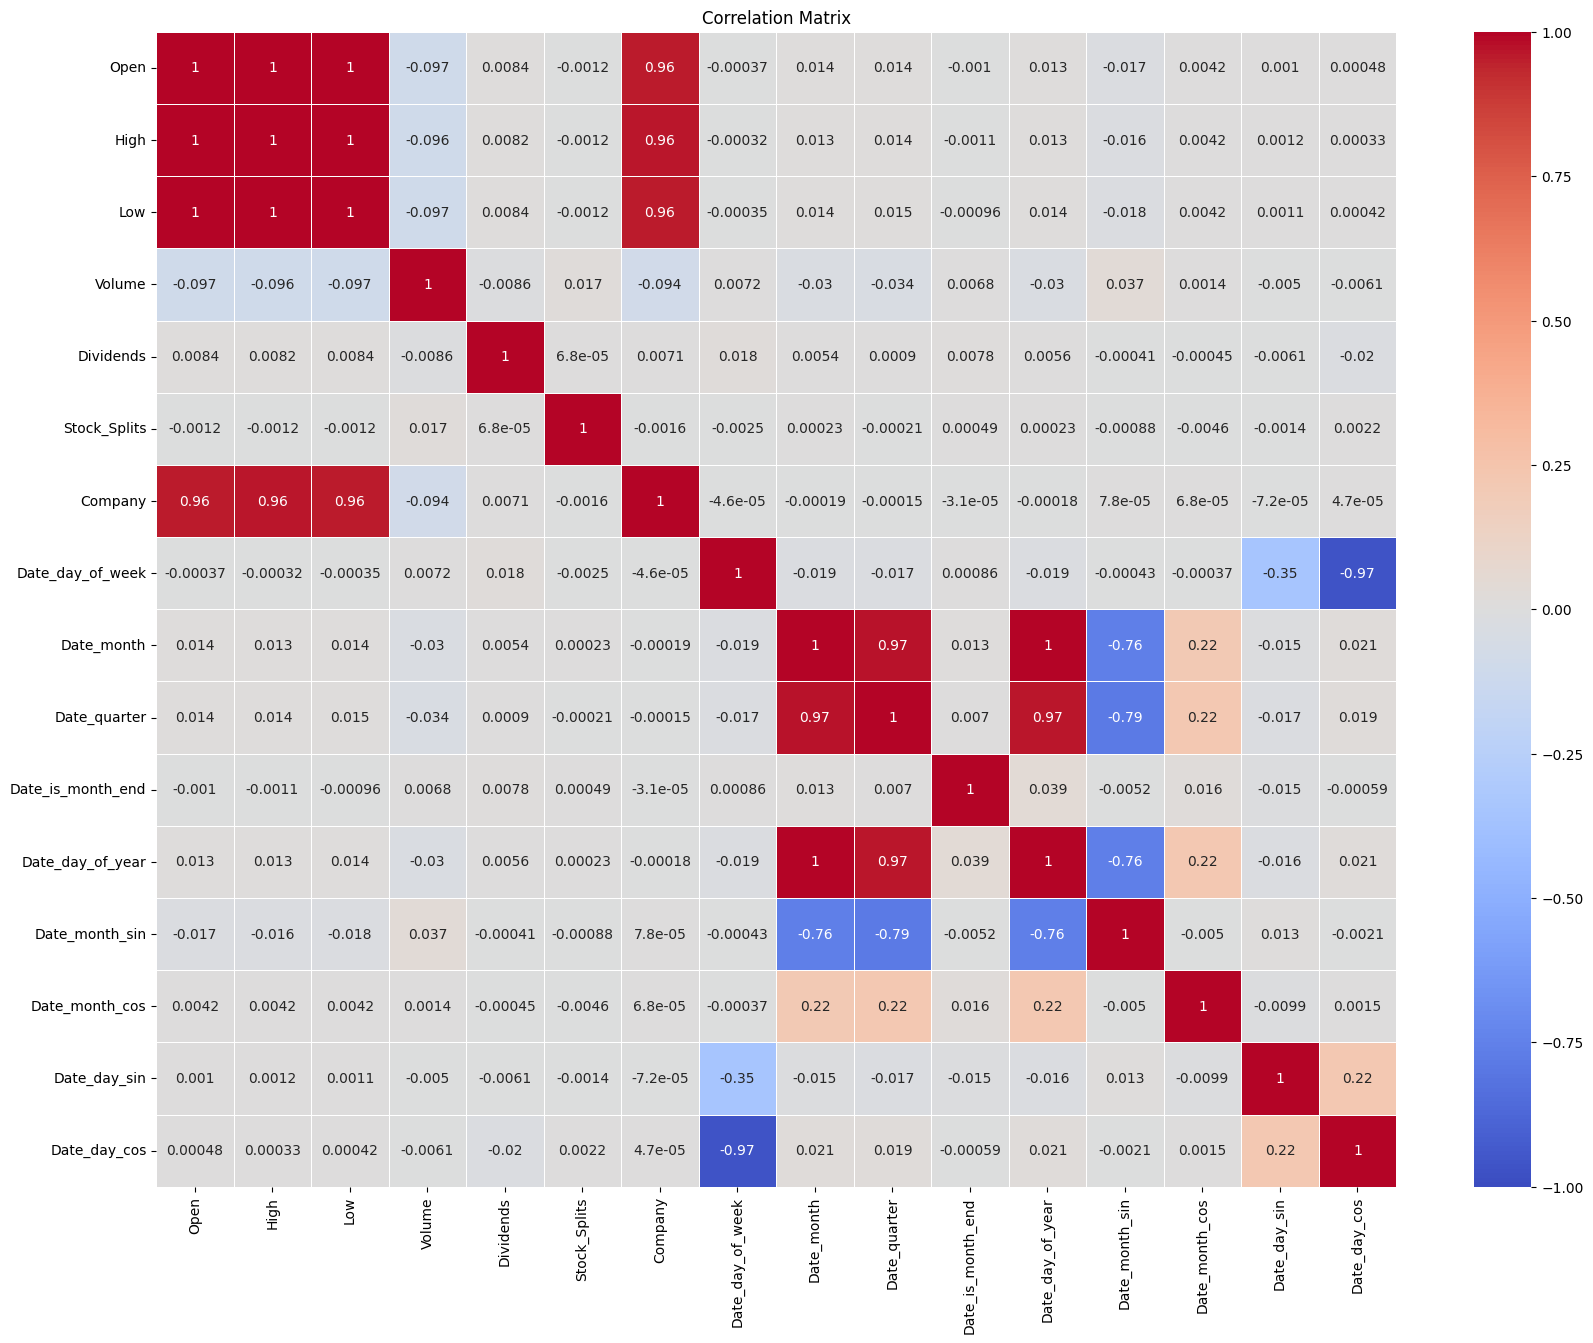

In [23]:
graphing_correlation_matrix(dataframe=X_train, zoom=5)

## Serving Features with Feast

In [24]:
"""
Simulating the Team 1 feature load
"""
ids_to_retrieve_features = writing_feature_table(dataframe=pd.concat([X_train, y_train], axis=1), file_name="companies_stock_feature_table", init_path="..")

Feature Table in /feast_service/fs_mle_03/feature_repo/data/companies_stock_feature_table.parquet


## Retrieving Features with Feast

In [25]:
"""
Simulating the Team 2 feature retrieve
"""
fs = FeatureStore(".."+FEAST_REPOSITORY_PATH)
entity_df = pd.DataFrame.from_dict({ID_FEATURE: ids_to_retrieve_features, "event_timestamp": [pd.Timestamp.now()] * len(ids_to_retrieve_features)})
total_features = fs.get_historical_features(entity_df=entity_df, features=fs.get_feature_service("companies_stock_feature_service")).to_df()

In [26]:
y_train = total_features[TARGET]
X_train = total_features.drop([TARGET], axis=1)

In [27]:
X_train

,companies_stock_id,event_timestamp,created,Open,High,Low,Volume,Dividends,Stock_Splits,Company,Date_day_of_week,Date_month,Date_quarter,Date_is_month_end,Date_day_of_year,Date_month_sin,Date_month_cos,Date_day_sin,Date_day_cos
0,a2dd736d-27f9-4edc-9a87-ea0c0b707cad,2025-11-13 00:27:40.468493+00:00,2025-11-13 00:27:37.589824+00:00,-0.350237,-0.352099,-0.352793,11.237094,-0.06138,-0.007209,-0.105278,0.699716,1.299335,1.333275,-0.187045,1.424347,-0.692120,1.240031,0.143086,-1.047608
1,7e72c706-40d4-4cc5-880c-3d6ae0375c21,2025-11-13 00:27:40.468493+00:00,2025-11-13 00:27:37.589828+00:00,-0.352483,-0.354407,-0.353437,10.612311,-0.06138,-0.007209,-0.105278,1.413786,1.299335,1.333275,5.346305,1.433897,-0.692120,1.240031,-1.542554,-1.047608
2,79f12dca-1caa-458b-a82f-201cb9504b9c,2025-11-13 00:27:40.468493+00:00,2025-11-13 00:27:37.589829+00:00,-0.348532,-0.350099,-0.349420,10.967057,-0.06138,-0.007209,-0.105278,-1.442492,1.591148,1.333275,-0.187045,1.462547,0.013542,1.429922,-0.699734,1.413059
3,c136595f-577b-4766-816b-b37e55b43950,2025-11-13 00:27:40.468493+00:00,2025-11-13 00:27:37.589830+00:00,-0.351858,-0.352482,-0.354168,11.118278,-0.06138,-0.007209,-0.105278,-0.728423,1.591148,1.333275,-0.187045,1.472097,0.013542,1.429922,0.818976,0.925694
4,459273b4-e4ff-4b31-9850-e8476898409d,2025-11-13 00:27:40.468493+00:00,2025-11-13 00:27:37.589831+00:00,-0.360566,-0.359594,-0.359790,11.607862,-0.06138,-0.007209,-0.105278,0.699716,1.591148,1.333275,-0.187045,1.491197,0.013542,1.429922,0.143086,-1.047608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
482168,725f4661-ef8d-4895-905d-6a071f88a684,2025-11-13 00:27:40.468493+00:00,2025-11-13 00:27:38.005461+00:00,-0.312248,-0.304444,-0.310258,-0.104869,-0.06138,-0.007209,-0.268424,-0.728423,1.299335,1.333275,-0.187045,1.214246,-0.692120,1.240031,0.818976,0.925694
482169,3a629f7f-6b34-42be-818a-9783feaeee6b,2025-11-13 00:27:40.468493+00:00,2025-11-13 00:27:38.005462+00:00,-0.305061,-0.306547,-0.309737,0.006356,-0.06138,-0.007209,-0.268424,-0.014353,1.299335,1.333275,-0.187045,1.223796,-0.692120,1.240031,1.194066,-0.169406
482170,2be8db0b-7c40-47bd-aa07-48b567a1c823,2025-11-13 00:27:40.468493+00:00,2025-11-13 00:27:38.005462+00:00,-0.321923,-0.320217,-0.324035,0.650139,-0.06138,-0.007209,-0.268424,0.699716,1.299335,1.333275,-0.187045,1.233346,-0.692120,1.240031,0.143086,-1.047608
482171,e66289d6-3325-4e3e-bcf5-a3c9aea0dfae,2025-11-13 00:27:40.468493+00:00,2025-11-13 00:27:38.005463+00:00,-0.317974,-0.318464,-0.319269,-0.016775,-0.06138,-0.007209,-0.268424,1.413786,1.299335,1.333275,-0.187045,1.242896,-0.692120,1.240031,-1.542554,-1.047608


In [28]:
y_train

0         43.083508
1         42.850754
2         44.348064
3         42.397247
4         41.924541
            ...    
482168    55.270000
482169    54.400002
482170    51.580002
482171    52.270000
482172    51.689999
Name: Close, Length: 482173, dtype: float64

## Saving artifacts

In [29]:
data = {
    "X_train": X_train.drop(columns=EXCLUDED_FEATURES),
    "y_train": y_train,
    "X_test": X_test,
    "y_test": y_test,
    "X_train_sample": X_train_sample,
    "y_train_sample": y_train_sample
}
joblib.dump(data, "../data/processed/processed_data.joblib")

['../data/processed/processed_data.joblib']